In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.feature import NaturalEarthFeature
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.cm import get_cmap
import metpy.calc as mpcalc
from metpy.units import units
from numpy import *
import numpy as np
import xarray as xr
from netCDF4 import Dataset, num2date
import math
import pygrib
import cdsapi
from datetime import datetime, timedelta

In [2]:
############# Declare time, level, and lat/lon boundaries here ##########
startdate = '02/01/26 00:00'    ## must be in this format 'MM/DD/YY HH:MM'
latN = 90
latS = 0
#lonW = -180    # must be in degrees E (The western hemisphere is captured between -180 and 0 degrees east)
#lonE = 0
lonW = 180   
lonE = 330   
date = datetime.strptime(startdate,'%m/%d/%y %H:%M')
level = 500

In [61]:
############### ONLY RUN THIS CELL ONCE TO ACQUIRE DATA #################
############### ONCE YOU HAVE RUN THIS CELL AND DOWNLOADED THE DATA YOU SHOULD COMMENT OUT ALL OF THE LINES BY PUTTING A # IN FRONT OF EVERY LINE #################
############### To see all of the possible data you can download from ERA5 go to the websites below. If you click "Show API Request" on the bottom of the page it will give you the info you can substitute in the request below for your own purposes 
############### Data on pressure levels: https://cds-beta.climate.copernicus.eu/datasets/reanalysis-era5-pressure-levels?tab=download
############### Data on single levels: https://cds-beta.climate.copernicus.eu/datasets/reanalysis-era5-single-levels?tab=download
"""
filestr = 'synoptic_'+date.strftime('%Y')+date.strftime('%m')+date.strftime('%d')+'_'+date.strftime('%H')+'00.nc'     # you can change these filenames as you see fit
filestr = '/gdex/data/d633000/e5.oper.an.pl/202602/e5.oper.an.pl.128_060_pv.ll025sc.2026020100_2026020123.nc'
print(filestr)      

######### Download ERA5 data using CDS-API ##########
client = cdsapi.Client()
dataset = "reanalysis-era5-pressure-levels"
request = {
    'product_type': ['reanalysis'],
    'variable': ['geopotential','temperature','u_component_of_wind','v_component_of_wind','vertical_velocity'],
    'year': [date.strftime('%Y')],
    'month': [date.strftime('%m')],
    'day': [date.strftime('%d')],
    'time': [date.strftime('%H:%M')],
    'pressure_level': [str(level)],
    'data_format': 'netcdf',
    'download_format': 'unarchived',
    'area': [latN, lonW, latS, lonE]
}
client.retrieve(dataset, request, filestr)
"""

'\nfilestr = \'synoptic_\'+date.strftime(\'%Y\')+date.strftime(\'%m\')+date.strftime(\'%d\')+\'_\'+date.strftime(\'%H\')+\'00.nc\'     # you can change these filenames as you see fit\nfilestr = \'/gdex/data/d633000/e5.oper.an.pl/202602/e5.oper.an.pl.128_060_pv.ll025sc.2026020100_2026020123.nc\'\nprint(filestr)      \n\n######### Download ERA5 data using CDS-API ##########\nclient = cdsapi.Client()\ndataset = "reanalysis-era5-pressure-levels"\nrequest = {\n    \'product_type\': [\'reanalysis\'],\n    \'variable\': [\'geopotential\',\'temperature\',\'u_component_of_wind\',\'v_component_of_wind\',\'vertical_velocity\'],\n    \'year\': [date.strftime(\'%Y\')],\n    \'month\': [date.strftime(\'%m\')],\n    \'day\': [date.strftime(\'%d\')],\n    \'time\': [date.strftime(\'%H:%M\')],\n    \'pressure_level\': [str(level)],\n    \'data_format\': \'netcdf\',\n    \'download_format\': \'unarchived\',\n    \'area\': [latN, lonW, latS, lonE]\n}\nclient.retrieve(dataset, request, filestr)\n'

In [3]:
######## Enter in the datasets #########
filepv = '/gdex/data/d633000/e5.oper.an.pl/202602/e5.oper.an.pl.128_060_pv.ll025sc.2026020100_2026020123.nc'
fileuwnd = '/gdex/data/d633000/e5.oper.an.pl/202602/e5.oper.an.pl.128_131_u.ll025uv.2026020100_2026020123.nc'
filevwnd = '/gdex/data/d633000/e5.oper.an.pl/202602/e5.oper.an.pl.128_132_v.ll025uv.2026020100_2026020123.nc'
filez = '/gdex/data/d633000/e5.oper.an.pl/202602/e5.oper.an.pl.128_129_z.ll025sc.2026020100_2026020123.nc'


dpv = xr.open_dataset(filepv).metpy.parse_cf()
duwnd = xr.open_dataset(fileuwnd).metpy.parse_cf()
dvwnd = xr.open_dataset(filevwnd).metpy.parse_cf()
dz = xr.open_dataset(filez).metpy.parse_cf()

#times = duwnd.time.values[::6]
date = duwnd.time.values[0]

######## Read in the variables ##########
uwnd = duwnd.U.metpy.sel(time=date,level=level,latitude=slice(latN,latS),longitude=slice(lonW,lonE))
lats = dpv.latitude.metpy.sel(latitude=slice(latN,latS))
lons = dpv.longitude.metpy.sel(longitude=slice(lonW,lonE))

lons_2D, lats_2D = meshgrid(lons,lats)
lats_2D = lats_2D * units.degrees

vwnd = dvwnd.V.metpy.sel(time=date,level=level,latitude=slice(latN,latS),longitude=slice(lonW,lonE))
geop = dz.Z.metpy.sel(time=date,level=level,latitude=slice(latN,latS),longitude=slice(lonW,lonE))
dx, dy = mpcalc.lat_lon_grid_deltas(lons, lats)
hght = geop/9.81    # need to divide the geopotential by gravity to get the geopotential height

corl = 2.0*7.292e-5*sin(lats*(pi/180.)) / units.second     # Coriolis Parameter

In [109]:
######### Apply a spatial smoother to the variables so that synoptic-scale signals can be more readily observed  ##########

######### A weight of "25" is used below, which is typically good for picking out synoptic-scale features. You can experiment with changing these weights to see the difference ##########
hght = mpcalc.smooth_gaussian(hght,25)
uwnd = mpcalc.smooth_gaussian(uwnd,25)
vwnd = mpcalc.smooth_gaussian(vwnd,25)

In [110]:
########### Calculate additional variables to plot #########
rvor = mpcalc.vorticity(uwnd,vwnd,dx=dx,dy=dy)
avor = mpcalc.absolute_vorticity(uwnd,vwnd,dx=dx,dy=dy,latitude=lats_2D * units.degrees)

########## Scale the vorticity so it plots correctly #########
scale = 5

/glade/u/apps/opt/miniforge/envs/npl-2026a/lib/python3.13/site-packages/pint/facets/plain/quantity.py:1031: RuntimeWarning: invalid value encountered in divide
  magnitude = magnitude_op(new_self._magnitude, other._magnitude)
/glade/u/apps/opt/miniforge/envs/npl-2026a/lib/python3.13/site-packages/pint/facets/plain/quantity.py:1031: RuntimeWarning: invalid value encountered in divide
  magnitude = magnitude_op(new_self._magnitude, other._magnitude)


/glade/derecho/scratch/zposner/tmp/ipykernel_44304/3089191534.py:34: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  rvor_fcontours = plt.contourf(lons_2D, lats_2D, rvor*10**scale, levels=rvor_levels, cmap=get_cmap('YlOrRd'), alpha=1, transform=ccrs.PlateCarree(),transform_first=True)


Text(1.0, 1.0, 'Valid:02/01/26 00:00')

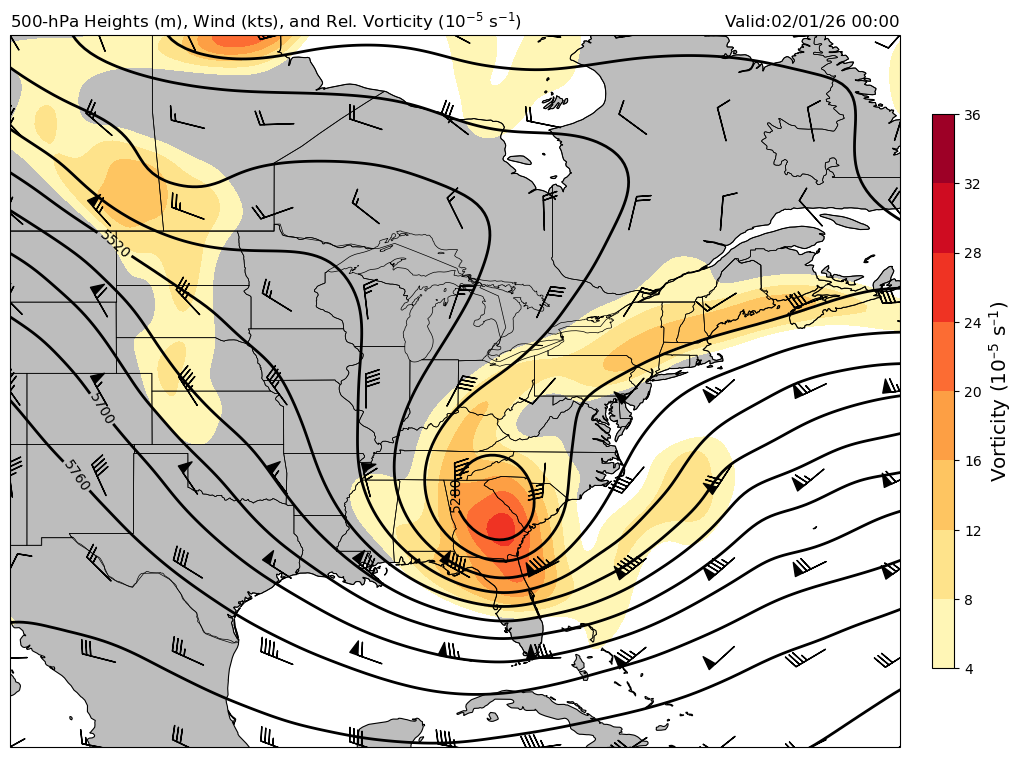

In [111]:
######## Create the plot #######

##### Set up the projection that will be used ##########
mapcrs = ccrs.LambertConformal(central_longitude=-55, central_latitude=45,
                               standard_parallels=(33, 45))
mapcrs = ccrs.PlateCarree()

# Set up the projection of the data; if lat/lon then PlateCarree is what you want
datacrs = ccrs.PlateCarree()

# Start the figure and create plot axes with proper projection
fig = plt.figure(1, figsize=(14, 12))
ax = plt.subplot(111, projection=mapcrs)
#ax.set_extent([-100, -10, 10, 70], ccrs.PlateCarree())    ## Can change the lat/lon bounds [West,East,South,North]
ax.set_extent([-110, -60, 20, 60], ccrs.PlateCarree())    ## Can change the lat/lon bounds [West,East,South,North]

# [-110, -60, 20, 60]

# Add geopolitical boundaries for map reference
ax.add_feature(cfeature.LAND, facecolor="#bdbdbd")
countries = NaturalEarthFeature(category="cultural", scale="110m", facecolor="none", name="admin_0_boundary_lines_land")
ax.add_feature(countries, linewidth=0.5, edgecolor="black")
ax.add_feature(cfeature.STATES.with_scale('50m'), linewidth=0.5)
ax.coastlines('50m', linewidth=0.8)

# Set up contour and fill intervals
hght_levels = arange(3000,7000,60)   # (min,max,interval)
rvor_levels = arange(4,40,4)
avor_levels = arange(8,40,4)

# Plot the variables

##### Plot the relative vorticity
rvor_fcontours = plt.contourf(lons_2D, lats_2D, rvor*10**scale, levels=rvor_levels, cmap=get_cmap('YlOrRd'), alpha=1, transform=ccrs.PlateCarree(),transform_first=True)

######Plot the absolute vorticity
#avor_fcontours = plt.contourf(lons_2D, lats_2D, avor*10**scale, levels=avor_levels, cmap=get_cmap('YlOrRd'), alpha=1, transform=ccrs.PlateCarree(),transform_first=True)

hght_contours = plt.contour(lons_2D, lats_2D, hght, levels=hght_levels, colors="black", linewidths=2.0, transform=ccrs.PlateCarree(),transform_first=True)

# Plot 500-hPa wind barbs in knots, regrid to reduce number of barbs
uwndbrb = uwnd.values * units.meter/units.second
vwndbrb = vwnd.values * units.meter/units.second
ax.barbs(lons[::20], lats[::20], uwndbrb.to('kt').m[::20,::20], vwndbrb.to('kt').m[::20,::20], pivot='middle',     ## change the '20' to filter the spatial density of wind barbs #
         color='black', transform=datacrs)

#### Colorbar and contour labels #####
### Color bar for relative vorticity
cb = fig.colorbar(rvor_fcontours, orientation='vertical', pad=0.03, extendrect=True, aspect=25, shrink=0.6)

### Color bar for absolute vorticity
#cb = fig.colorbar(avor_fcontours, orientation='vertical', pad=0.03, extendrect=True, aspect=25, shrink=0.6)

cb.set_label('Vorticity (10$^{–5}$ s$^{–1}$)', size='x-large')
plt.clabel(hght_contours, fmt='%d')

##### Plot two titles, one on right and left side ######
plt.title('500-hPa Heights (m), Wind (kts), and Rel. Vorticity (10$^{-5}$ s$^{-1}$)', loc='left')
plt.title('Valid:'+startdate, loc='right')

##### Save figure #####
#fig.savefig('[insert_name].pdf')    # change file name #